In [1]:

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
import h5py 

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from keras import regularizers


from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from keras.optimizers import Adam

print(tf.__version__)

Using TensorFlow backend.


2.2.0-rc3


Google SVHN Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
h5f= h5py.File('/content/drive/My Drive/Colab Notebooks/SVHN_single_grey1.h5','r')
list(h5f.keys())

['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

In [4]:
X_train=h5f['X_train'][:]
y_train =h5f['y_train'][:]

X_test=h5f['X_test'][:]
y_test =h5f['y_test'][:]

X_val=h5f['X_val'][:]
y_val =h5f['y_val'][:]
h5f.close()

print('Training set', X_train.shape, y_train.shape)
print('Validation set', X_val.shape, y_val.shape)
print('Test set', X_test.shape, y_test.shape)





Training set (42000, 32, 32) (42000,)
Validation set (60000, 32, 32) (60000,)
Test set (18000, 32, 32) (18000,)


Check unique Labels

In [5]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


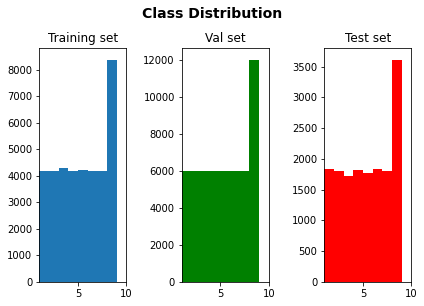

In [6]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharex=True)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.05)

ax1.hist(y_train, bins=9)
ax1.set_title("Training set")
ax1.set_xlim(1, 10)

ax2.hist(y_val, color='g', bins=9)
ax2.set_title("Val set")

ax3.hist(y_test, color='r', bins=9)
ax3.set_title("Test set")

fig.tight_layout()

The data set skewed towards 9 but otherwise looks like a balanced classification

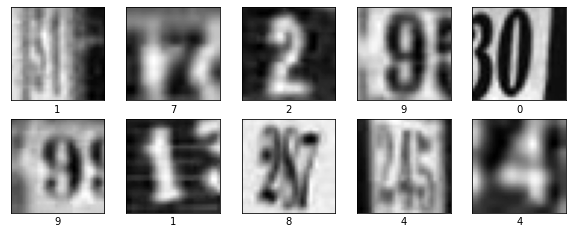

In [7]:

plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    plt.xlabel(y_test[i])
plt.show()

**ADAM OPTIMIZATION .**

In [0]:
X_train_google_cpy = X_train / 255


X_test_google_cpy = X_test / 255


X_val_google_cpy = X_val / 255

TRY WITH 
1. CHANGING NETWORK
2. ADDING BATCH NORMALIZATION BETWEEN EVERY STEP 


In [0]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
   # keras.layers.Dense(32, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(10)
])

CHANGED THE NETWORK BUT ABOVE ONE WAS FOUND TO BE GOOD.

TRY WITH
BATCH SIZE  32,64,128

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=25,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/25
1313/1313 [==============================] - 7s 5ms/step - loss: 1.3751 - accuracy: 0.5523 - val_loss: 0.9324 - val_accuracy: 0.7132
Epoch 2/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.9724 - accuracy: 0.6917 - val_loss: 0.8008 - val_accuracy: 0.7545
Epoch 3/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8477 - accuracy: 0.7343 - val_loss: 0.7078 - val_accuracy: 0.7855
Epoch 4/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7813 - accuracy: 0.7554 - val_loss: 0.6223 - val_accuracy: 0.8140
Epoch 5/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7367 - accuracy: 0.7683 - val_loss: 0.5824 - val_accuracy: 0.8302
Epoch 6/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.6952 - accuracy: 0.7835 - val_loss: 0.5729 - val_accuracy: 0.8290
Epoch 7/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.6697 - accuracy: 0.7901 - val_loss: 0.5483 - val_accuracy:

In [11]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32:', test_acc)

563/563 - 1s - loss: 0.5403 - accuracy: 0.8475

Test accuracy with Adam batch size = 32: 0.8475000262260437


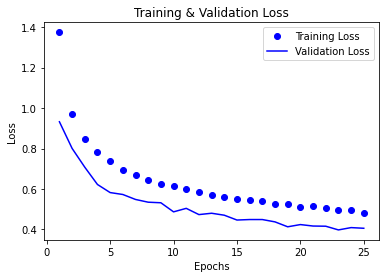

In [12]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
   # keras.layers.Dense(32, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=25,batch_size= 64,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/25
657/657 [==============================] - 5s 7ms/step - loss: 1.3587 - accuracy: 0.5611 - val_loss: 0.9675 - val_accuracy: 0.7037
Epoch 2/25
657/657 [==============================] - 4s 7ms/step - loss: 0.9250 - accuracy: 0.7123 - val_loss: 0.8005 - val_accuracy: 0.7567
Epoch 3/25
657/657 [==============================] - 4s 7ms/step - loss: 0.8032 - accuracy: 0.7492 - val_loss: 0.6869 - val_accuracy: 0.7917
Epoch 4/25
657/657 [==============================] - 4s 6ms/step - loss: 0.7296 - accuracy: 0.7742 - val_loss: 0.6397 - val_accuracy: 0.8091
Epoch 5/25
657/657 [==============================] - 4s 7ms/step - loss: 0.6820 - accuracy: 0.7891 - val_loss: 0.6042 - val_accuracy: 0.8188
Epoch 6/25
657/657 [==============================] - 4s 7ms/step - loss: 0.6413 - accuracy: 0.8014 - val_loss: 0.6022 - val_accuracy: 0.8182
Epoch 7/25
657/657 [==============================] - 4s 7ms/step - loss: 0.6119 - accuracy: 0.8097 - val_loss: 0.5528 - val_accuracy: 0.8348
Epoch 

In [14]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 64:', test_acc)

563/563 - 1s - loss: 0.5701 - accuracy: 0.8423

Test accuracy with Adam batch size = 64: 0.8423333168029785


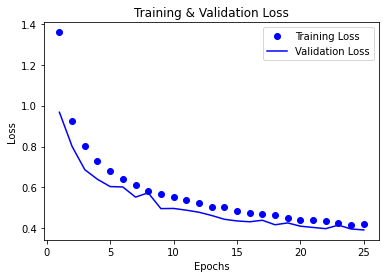

In [16]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
   # keras.layers.Dense(32, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=50,batch_size= 128,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/50
329/329 [==============================] - 3s 10ms/step - loss: 1.4157 - accuracy: 0.5447 - val_loss: 1.0591 - val_accuracy: 0.6880
Epoch 2/50
329/329 [==============================] - 3s 9ms/step - loss: 0.9204 - accuracy: 0.7135 - val_loss: 0.8259 - val_accuracy: 0.7470
Epoch 3/50
329/329 [==============================] - 3s 9ms/step - loss: 0.7916 - accuracy: 0.7568 - val_loss: 0.7235 - val_accuracy: 0.7791
Epoch 4/50
329/329 [==============================] - 3s 9ms/step - loss: 0.7141 - accuracy: 0.7819 - val_loss: 0.6701 - val_accuracy: 0.7982
Epoch 5/50
329/329 [==============================] - 3s 9ms/step - loss: 0.6603 - accuracy: 0.7982 - val_loss: 0.5963 - val_accuracy: 0.8208
Epoch 6/50
329/329 [==============================] - 3s 9ms/step - loss: 0.6188 - accuracy: 0.8107 - val_loss: 0.5750 - val_accuracy: 0.8281
Epoch 7/50
329/329 [==============================] - 3s 9ms/step - loss: 0.5883 - accuracy: 0.8200 - val_loss: 0.5492 - val_accuracy: 0.8363
Epoch

In [18]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 128:', test_acc)

563/563 - 1s - loss: 0.6327 - accuracy: 0.8413

Test accuracy with Adam batch size = 128: 0.8413333296775818


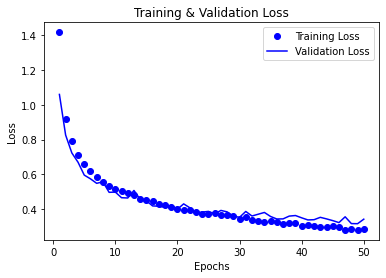

In [19]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

CONCLUSION: LOOKS LIKE BATCH SIZE OF 32  IS SLIGHTLY BETTER .


Test accuracy with Adam ,batch size = 32: 0.8475000262260437 loss: 0.5403 25 epch

Test accuracy with Adam, batch size = 64: 0.8423333168029785 loss 0.5701 25 epch



Test accuracy with Adam batch size = 128: 0.8413333296775818 loss: 0.6327 50 epch




**LET US INTRODUCE DROP OUT AND CHECK WHERE WE GO**

In [0]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
  
    keras.layers.Dense(10)
])

In [21]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=25,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/25
1313/1313 [==============================] - 7s 5ms/step - loss: 1.5118 - accuracy: 0.4940 - val_loss: 0.9723 - val_accuracy: 0.7021
Epoch 2/25
1313/1313 [==============================] - 7s 5ms/step - loss: 1.0745 - accuracy: 0.6580 - val_loss: 0.8341 - val_accuracy: 0.7424
Epoch 3/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.9474 - accuracy: 0.7013 - val_loss: 0.7222 - val_accuracy: 0.7847
Epoch 4/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8741 - accuracy: 0.7245 - val_loss: 0.6769 - val_accuracy: 0.7965
Epoch 5/25
1313/1313 [==============================] - 10s 8ms/step - loss: 0.8258 - accuracy: 0.7400 - val_loss: 0.6395 - val_accuracy: 0.8080
Epoch 6/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7855 - accuracy: 0.7562 - val_loss: 0.6057 - val_accuracy: 0.8197
Epoch 7/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7562 - accuracy: 0.7647 - val_loss: 0.5889 - val_accuracy

In [22]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32 AND DROPOUT 0.2:', test_acc)

563/563 - 1s - loss: 0.5063 - accuracy: 0.8552

Test accuracy with Adam batch size = 32 AND DROPOUT 0.2: 0.855222225189209


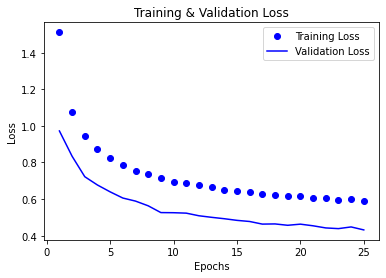

In [23]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation='relu'),
  
    keras.layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=25,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/25
1313/1313 [==============================] - 7s 6ms/step - loss: 1.4360 - accuracy: 0.5247 - val_loss: 0.9810 - val_accuracy: 0.6960
Epoch 2/25
1313/1313 [==============================] - 7s 5ms/step - loss: 1.0274 - accuracy: 0.6739 - val_loss: 0.8159 - val_accuracy: 0.7481
Epoch 3/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.9003 - accuracy: 0.7151 - val_loss: 0.7000 - val_accuracy: 0.7904
Epoch 4/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8309 - accuracy: 0.7398 - val_loss: 0.6420 - val_accuracy: 0.8093
Epoch 5/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7819 - accuracy: 0.7549 - val_loss: 0.6295 - val_accuracy: 0.8095
Epoch 6/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7426 - accuracy: 0.7696 - val_loss: 0.5860 - val_accuracy: 0.8283
Epoch 7/25
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7150 - accuracy: 0.7774 - val_loss: 0.5696 - val_accuracy:

In [26]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32 AND DROPOUT 0.1:', test_acc)

563/563 - 1s - loss: 0.5259 - accuracy: 0.8498

Test accuracy with Adam batch size = 32 AND DROPOUT 0.1: 0.8498333096504211




Test accuracy with Adam batch size = 32 AND DROPOUT 0.2: 0.855222225189209 loss: 0.5063

Test accuracy with Adam batch size = 32 AND DROPOUT 0.1: 0.8498333096504211 loss: 0.5259

DROP OUT 0.2 is better as lower loss and better accuracy.

In [0]:
X_train=X_train.reshape((42000, 32* 32))
X_train = X_train.astype('float32') / 255

X_test=X_test.reshape((18000, 32* 32))
X_test = X_test.astype('float32') / 255

X_val=X_val.reshape((60000, 32* 32))
X_val = X_val.astype('float32') / 255



In [0]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test= to_categorical(y_test)
y_val= to_categorical(y_val)


In [0]:
model = keras.Sequential([
  
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation='relu'),
    #keras.layers.Dropout(0.1),
   
    keras.layers.Dense(256, activation='relu'),
    #keras.layers.Dense(128, activation='relu'),
    #keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    
    keras.layers.Dense(10,activation='softmax')
])

In [0]:

#model.compile(optimizer='keras.optimizers.Adam()',
 #             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  #            metrics=['accuracy'])

In [0]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

In [13]:
history = model.fit(X_train, y_train, epochs=25,batch_size= 128,validation_data=(X_val,y_val)
          )

Epoch 1/25
329/329 [==============================] - 9s 26ms/step - loss: 1.7006 - accuracy: 0.4201 - val_loss: 1.3327 - val_accuracy: 0.5740
Epoch 2/25
329/329 [==============================] - 8s 26ms/step - loss: 1.0328 - accuracy: 0.6753 - val_loss: 1.3045 - val_accuracy: 0.6378
Epoch 3/25
329/329 [==============================] - 9s 26ms/step - loss: 0.8319 - accuracy: 0.7388 - val_loss: 1.3198 - val_accuracy: 0.6907
Epoch 4/25
329/329 [==============================] - 8s 26ms/step - loss: 0.7267 - accuracy: 0.7750 - val_loss: 0.7369 - val_accuracy: 0.7676
Epoch 5/25
329/329 [==============================] - 8s 26ms/step - loss: 0.6632 - accuracy: 0.7933 - val_loss: 0.8031 - val_accuracy: 0.7544
Epoch 6/25
329/329 [==============================] - 8s 26ms/step - loss: 0.6075 - accuracy: 0.8113 - val_loss: 0.7584 - val_accuracy: 0.7765
Epoch 7/25
329/329 [==============================] - 8s 25ms/step - loss: 0.5625 - accuracy: 0.8235 - val_loss: 0.7259 - val_accuracy: 0.7837

In [22]:
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy with rmsprop:', test_acc)

563/563 - 1s - loss: 0.8339 - accuracy: 0.8531

Test accuracy with rmsprop: 0.8530555367469788


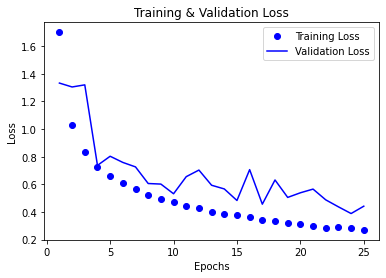

In [15]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

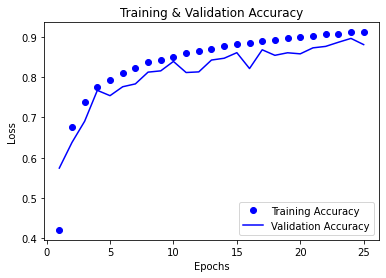

In [16]:
plt.clf()

acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [0]:
model.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])

In [23]:
history = model.fit(X_train, y_train, epochs=50,batch_size= 128,validation_data=(X_val,y_val)
          )

Epoch 1/50
329/329 [==============================] - 8s 24ms/step - loss: 0.0953 - accuracy: 0.9694 - val_loss: 0.3368 - val_accuracy: 0.9291
Epoch 2/50
329/329 [==============================] - 8s 24ms/step - loss: 0.0939 - accuracy: 0.9698 - val_loss: 0.3386 - val_accuracy: 0.9329
Epoch 3/50
329/329 [==============================] - 8s 25ms/step - loss: 0.0931 - accuracy: 0.9703 - val_loss: 0.2961 - val_accuracy: 0.9418
Epoch 4/50
329/329 [==============================] - 8s 24ms/step - loss: 0.0912 - accuracy: 0.9712 - val_loss: 0.3356 - val_accuracy: 0.9321
Epoch 5/50
329/329 [==============================] - 8s 24ms/step - loss: 0.0909 - accuracy: 0.9708 - val_loss: 0.2838 - val_accuracy: 0.9449
Epoch 6/50
329/329 [==============================] - 8s 24ms/step - loss: 0.0927 - accuracy: 0.9712 - val_loss: 0.2788 - val_accuracy: 0.9462
Epoch 7/50
329/329 [==============================] - 8s 24ms/step - loss: 0.0886 - accuracy: 0.9722 - val_loss: 1.1292 - val_accuracy: 0.8078

In [24]:
test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy with SGD:', test_acc)

563/563 - 1s - loss: 0.9429 - accuracy: 0.8591

Test accuracy with SGD: 0.8590555787086487


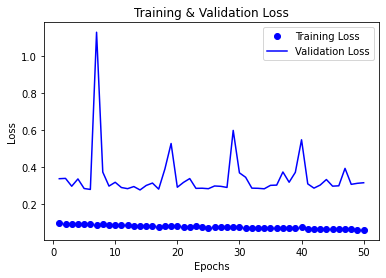

In [25]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

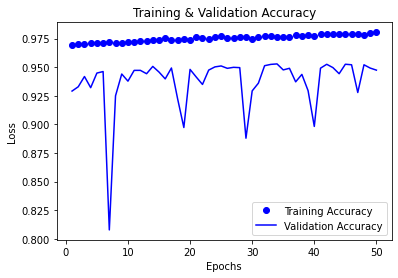

In [26]:
plt.clf()

acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()